In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#libraries for file handling and numerical work
import os
import time
import random
import numpy as np
import pandas as pd

# Libraries for graphs and visualizations
import matplotlib.pyplot as plt

# TensorFlow and Keras are used for building deep learning models
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img

# MobileNetV2 is used for transfer learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Sklearn is used for evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
# This is the location of my extracted traffic sign dataset in Google Drive.
# Change this path only if your folder name/location is different.

dataset_path = "/content/drive/MyDrive/Traffic_sign"

train_dir = os.path.join(dataset_path, "Train")
test_dir = os.path.join(dataset_path, "Test")

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

Train folder exists: True
Test folder exists: True


In [7]:
#Understanding dataset

# Ignore hidden files like .DS_Store
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if not folder.startswith(".")
    and os.path.isdir(os.path.join(train_dir, folder))
])

print("Total classes:", len(class_names))
print("Class names:", class_names)

# Count training images
train_counts = {}

for class_name in class_names:

    train_class_path = os.path.join(train_dir, class_name)

    train_counts[class_name] = len([
        file for file in os.listdir(train_class_path)
        if not file.startswith(".")
    ])

print("\nTraining image count per class:")
print(train_counts)

# Count total test images
test_image_count = len([
    file for file in os.listdir(test_dir)
    if not file.startswith(".")
])

print("\nTotal unlabeled test images:")
print(test_image_count)

Total classes: 4
Class names: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']

Training image count per class:
{'Caution': 2422, 'Instructions': 2841, 'No Passing': 5362, 'OverSpeed': 5242}

Total unlabeled test images:
4


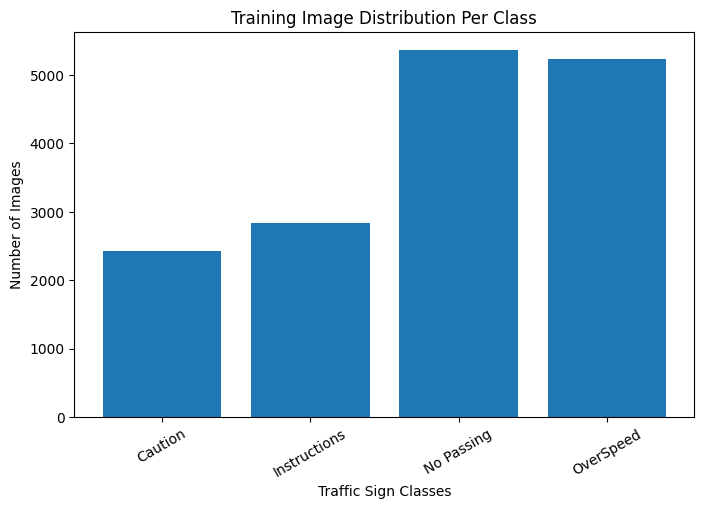

In [8]:
# This graph helps me understand whether the dataset is balanced or imbalanced.

plt.figure(figsize=(8,5))
plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Image Distribution Per Class")
plt.xlabel("Traffic Sign Classes")

plt.ylabel("Number of Images")

plt.xticks(rotation=30)
plt.show()

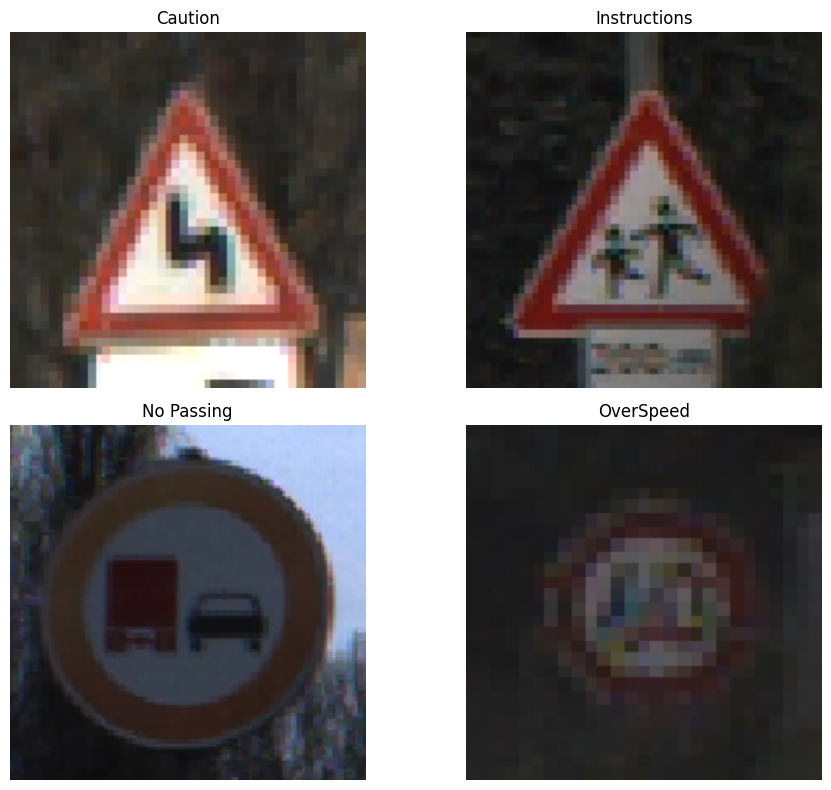

In [9]:
# I am displaying one random image from each class.
# This helps me visually understand what type of images are present in the dataset.
plt.figure(figsize=(10,8))
for i, class_name in enumerate(class_names):

    class_folder = os.path.join(train_dir, class_name)
    sample_image_name = random.choice(os.listdir(class_folder))
    sample_image_path = os.path.join(class_folder, sample_image_name)
    img = load_img(sample_image_path, target_size=(128,128))

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# REMOVING CORRUPTED OR NON-IMAGE FILES

from PIL import Image

bad_files = []

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

for class_name in class_names:

    class_path = os.path.join(train_dir, class_name)

    for file_name in os.listdir(class_path):

        file_path = os.path.join(class_path, file_name)

        # Skip folders
        if not os.path.isfile(file_path):
            continue

        # Remove hidden files
        if file_name.startswith("."):
            bad_files.append(file_path)
            continue

        # Remove invalid file extensions
        if not file_name.lower().endswith(valid_extensions):
            bad_files.append(file_path)
            continue

        # Verify image
        try:
            img = Image.open(file_path)
            img.verify()

        except Exception:
            bad_files.append(file_path)

print("Bad files found:", len(bad_files))

for file in bad_files:
    print(file)

# Delete bad files
for file in bad_files:
    os.remove(file)

print("\nBad files removed successfully.")

Bad files found: 0

Bad files removed successfully.


In [11]:
# IMAGE PREPROCESSING AND DATA SPLITTING

IMG_SIZE = (128,128)

BATCH_SIZE = 32

# Data augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Training data
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Validation data
val_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

num_classes = len(train_data.class_indices)

print("Class mapping:")
print(train_data.class_indices)

Found 11109 images belonging to 4 classes.
Found 4758 images belonging to 4 classes.
Class mapping:
{'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}


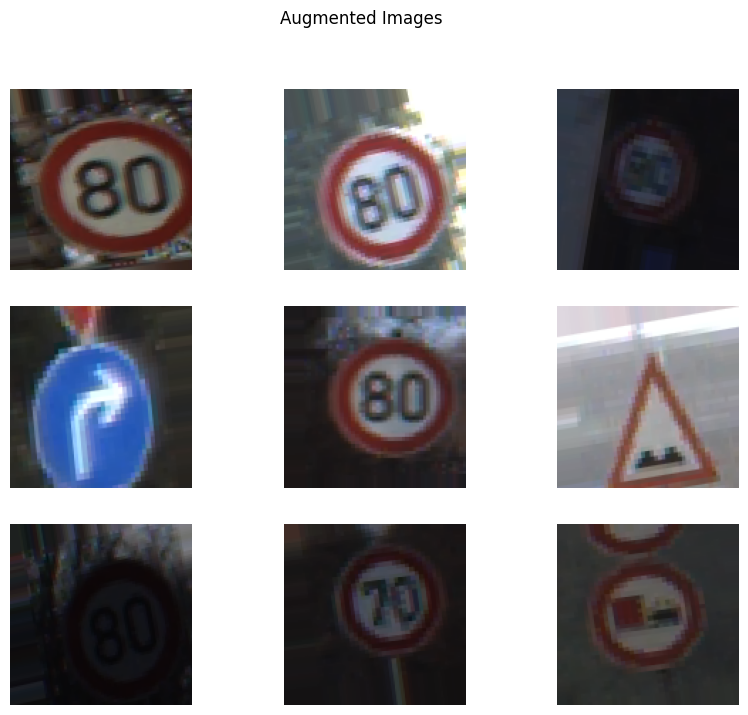

In [12]:
# DISPLAY AUGMENTED IMAGES

images, labels = next(train_data)

plt.figure(figsize=(10,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.suptitle("Augmented Images")

plt.show()

In [13]:
# BASELINE CNN MODEL

baseline_model = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,444 (25.01 MB)

 Trainable params: 6,557,444 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# TRAIN BASELINE CNN

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

baseline_history = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

baseline_time = time.time() - start_time

print("Baseline training time:", round(baseline_time,2), "seconds")

Epoch 1/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 144s 391ms/step - accuracy: 0.8918 - loss: 0.2829 - val_accuracy: 0.6574 - val_loss: 3.0539
Epoch 2/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 118s 340ms/step - accuracy: 0.9796 - loss: 0.0662 - val_accuracy: 0.7108 - val_loss: 3.1469
Epoch 3/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 118s 340ms/step - accuracy: 0.9905 - loss: 0.0318 - val_accuracy: 0.6820 - val_loss: 2.4880
Epoch 4/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 118s 340ms/step - accuracy: 0.9880 - loss: 0.0405 - val_accuracy: 0.6757 - val_loss: 4.4539
Epoch 5/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 125s 359ms/step - accuracy: 0.9951 - loss: 0.0185 - val_accuracy: 0.6347 - val_loss: 5.6324
Baseline training time: 625.27 seconds


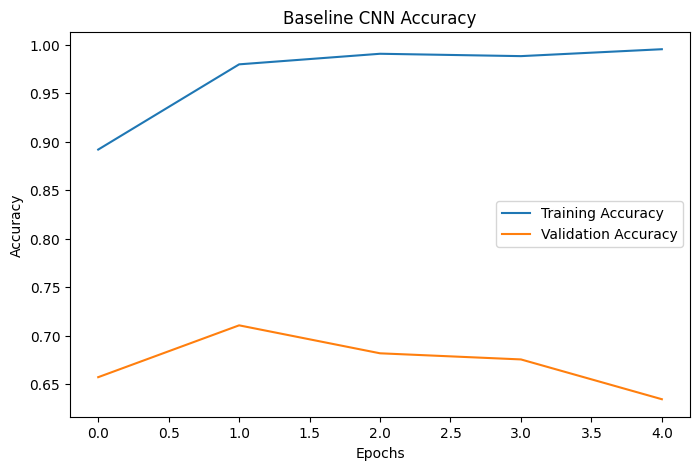

In [15]:
# BASELINE ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline CNN Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()


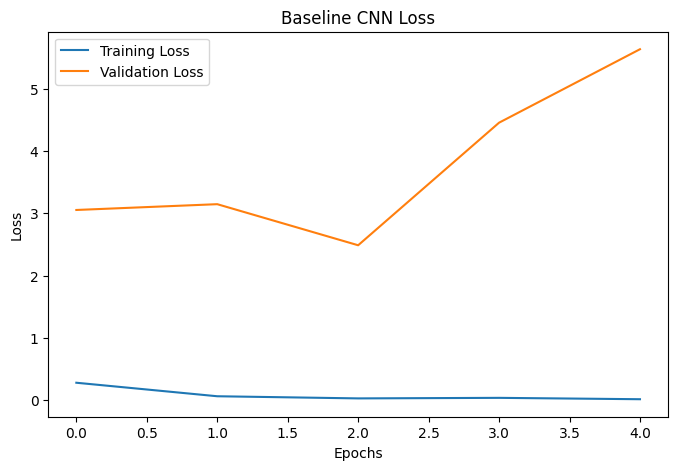

In [16]:
# BASELINE LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")

plt.title("Baseline CNN Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [17]:
# EVALUATE BASELINE CNN

baseline_loss, baseline_acc = baseline_model.evaluate(val_data)

print("Baseline Accuracy:", round(baseline_acc * 100,2), "%")
print("Baseline Loss:", round(baseline_loss,4))

149/149 ━━━━━━━━━━━━━━━━━━━━ 44s 299ms/step - accuracy: 0.6831 - loss: 2.4741
Baseline Accuracy: 68.31 %
Baseline Loss: 2.4741


In [18]:
# DEEPER CNN MODEL WITH REGULARIZATION

deeper_model_adam = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

deeper_model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_model_adam.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,786,372 (10.63 MB)

 Trainable params: 2,784,388 (10.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [19]:
# TRAIN DEEPER CNN

start_time = time.time()

deeper_history_adam = deeper_model_adam.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

deeper_adam_time = time.time() - start_time

print("Deeper CNN training time:", round(deeper_adam_time,2), "seconds")

Epoch 1/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 141s 371ms/step - accuracy: 0.8426 - loss: 0.4934 - val_accuracy: 0.4649 - val_loss: 1.8694
Epoch 2/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 125s 360ms/step - accuracy: 0.9811 - loss: 0.0629 - val_accuracy: 0.4849 - val_loss: 6.0850
Epoch 3/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 134s 337ms/step - accuracy: 0.9760 - loss: 0.1140 - val_accuracy: 0.6219 - val_loss: 5.3582
Epoch 4/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 119s 343ms/step - accuracy: 0.9921 - loss: 0.0249 - val_accuracy: 0.6791 - val_loss: 6.4909
Epoch 5/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 118s 340ms/step - accuracy: 0.9934 - loss: 0.0263 - val_accuracy: 0.7026 - val_loss: 3.1630
Epoch 6/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 120s 346ms/step - accuracy: 0.9940 - loss: 0.0239 - val_accuracy: 0.6606 - val_loss: 3.6493
Deeper CNN training time: 758.8 seconds


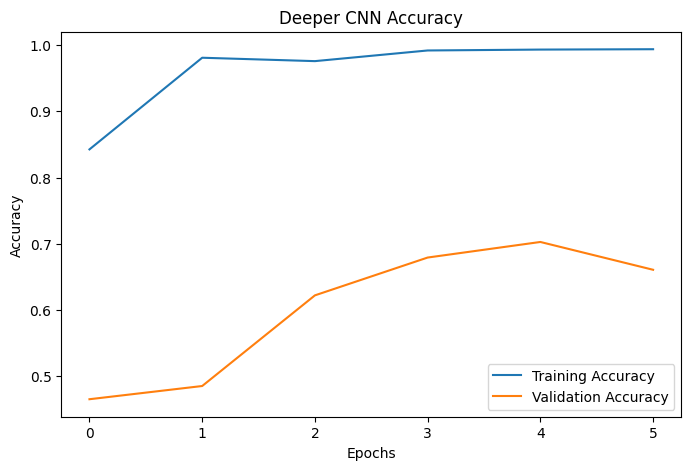

In [20]:
# DEEPER CNN ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    deeper_history_adam.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    deeper_history_adam.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Deeper CNN Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


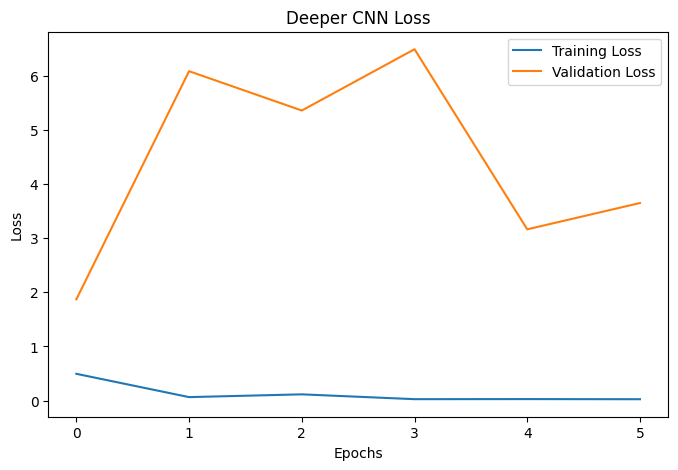

In [21]:

# DEEPER CNN LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    deeper_history_adam.history["loss"],
    label="Training Loss"
)

plt.plot(
    deeper_history_adam.history["val_loss"],
    label="Validation Loss"
)

plt.title("Deeper CNN Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [25]:
# EVALUATING DEEPER CNN

deeper_adam_loss, deeper_adam_acc = deeper_model_adam.evaluate(val_data)

print("Deeper CNN Accuracy:", round(deeper_adam_acc * 100,2), "%")
print("Deeper CNN Loss:", round(deeper_adam_loss,4))

149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 246ms/step - accuracy: 0.4624 - loss: 1.8993
Deeper CNN Accuracy: 46.24 %
Deeper CNN Loss: 1.8993


In [26]:
# TRANSFER LEARNING DATA PREPROCESSING

TRANSFER_IMG_SIZE = (224,224)

transfer_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.3,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

transfer_train_data = transfer_datagen.flow_from_directory(
    train_dir,
    target_size=TRANSFER_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

transfer_val_data = transfer_datagen.flow_from_directory(
    train_dir,
    target_size=TRANSFER_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 11109 images belonging to 4 classes.
Found 4758 images belonging to 4 classes.


In [27]:
# TRANSFER LEARNING MODEL

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.4)(x)

output = Dense(num_classes, activation="softmax")(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
# TRAIN TRANSFER LEARNING MODEL

start_time = time.time()

transfer_history = transfer_model.fit(
    transfer_train_data,
    validation_data=transfer_val_data,
    epochs=5,
    callbacks=[early_stop]
)

transfer_time = time.time() - start_time

print("Transfer Learning training time:", round(transfer_time,2), "seconds")

Epoch 1/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 316s 848ms/step - accuracy: 0.9090 - loss: 0.2425 - val_accuracy: 0.7858 - val_loss: 1.8726
Epoch 2/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 237s 680ms/step - accuracy: 0.9674 - loss: 0.0939 - val_accuracy: 0.7652 - val_loss: 2.0430
Epoch 3/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 239s 688ms/step - accuracy: 0.9743 - loss: 0.0716 - val_accuracy: 0.7999 - val_loss: 2.0415
Epoch 4/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 237s 681ms/step - accuracy: 0.9770 - loss: 0.0598 - val_accuracy: 0.7902 - val_loss: 2.4046
Epoch 5/5
348/348 ━━━━━━━━━━━━━━━━━━━━ 264s 687ms/step - accuracy: 0.9783 - loss: 0.0556 - val_accuracy: 0.7785 - val_loss: 2.6591
Transfer Learning training time: 1295.13 seconds


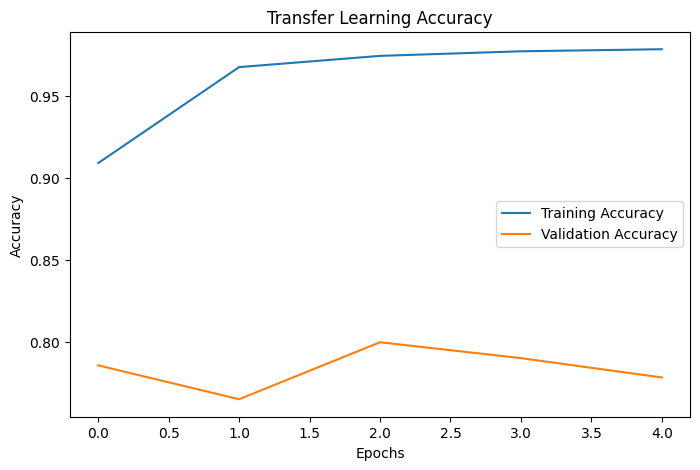

In [29]:
#Accuracy Graph for Transfer Learning

plt.figure(figsize=(8,5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Transfer Learning Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

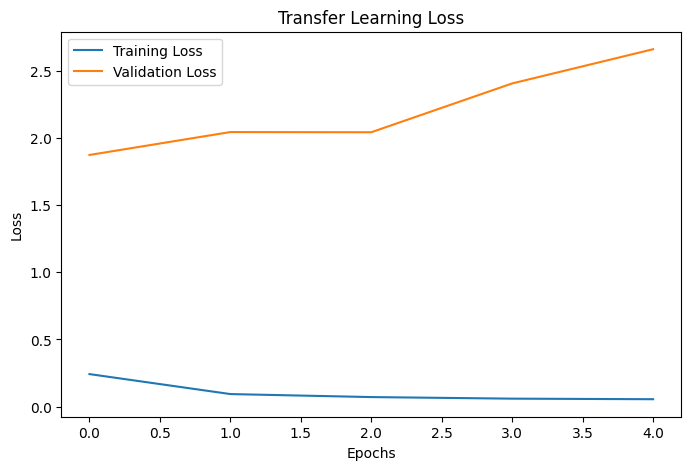

In [31]:
#Transfer learning Loss graph
plt.figure(figsize=(8,5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Transfer Learning Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [30]:
# EVALUATE TRANSFER LEARNING MODEL

transfer_loss, transfer_acc = transfer_model.evaluate(transfer_val_data)

print("Transfer Learning Accuracy:", round(transfer_acc * 100,2), "%")
print("Transfer Learning Loss:", round(transfer_loss,4))

149/149 ━━━━━━━━━━━━━━━━━━━━ 73s 489ms/step - accuracy: 0.7875 - loss: 1.8464
Transfer Learning Accuracy: 78.75 %
Transfer Learning Loss: 1.8464


149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 486ms/step
              precision    recall  f1-score   support

     Caution       0.55      0.99      0.71       726
Instructions       0.80      0.36      0.50       852
  No Passing       0.95      0.79      0.86      1608
   OverSpeed       0.83      0.92      0.88      1572

    accuracy                           0.79      4758
   macro avg       0.78      0.76      0.73      4758
weighted avg       0.82      0.79      0.78      4758



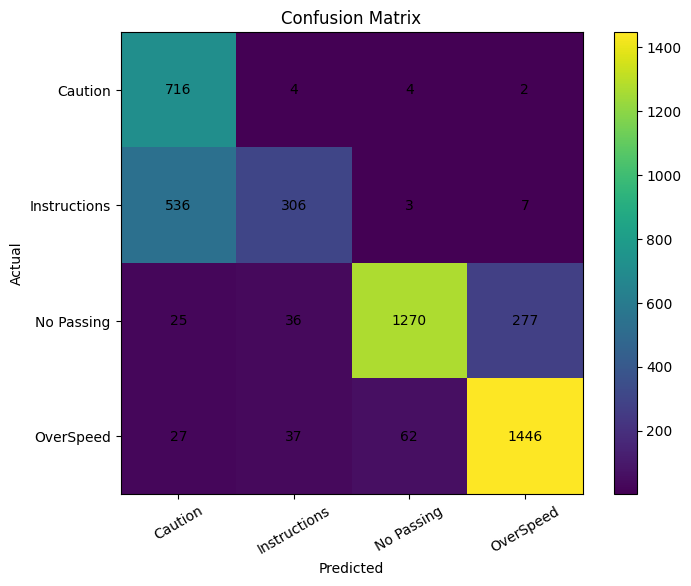

In [33]:
# CONFUSION MATRIX AND CLASSIFICATION REPORT

y_true = transfer_val_data.classes

y_pred_prob = transfer_model.predict(transfer_val_data)

y_pred = np.argmax(y_pred_prob, axis=1)

labels = list(transfer_val_data.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=labels
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(np.arange(len(labels)), labels, rotation=30)
plt.yticks(np.arange(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

               Model  Accuracy
0       Baseline CNN     68.31
1         Deeper CNN     46.24
2  Transfer Learning     78.75


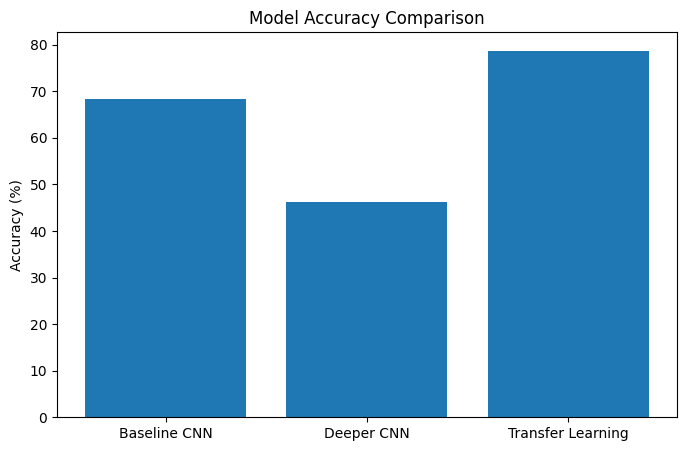

In [34]:
# MODEL COMPARISON

results = {
    "Baseline CNN": baseline_acc,
    "Deeper CNN": deeper_adam_acc,
    "Transfer Learning": transfer_acc
}

results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [round(v * 100,2) for v in results.values()]
})

print(results_df)

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


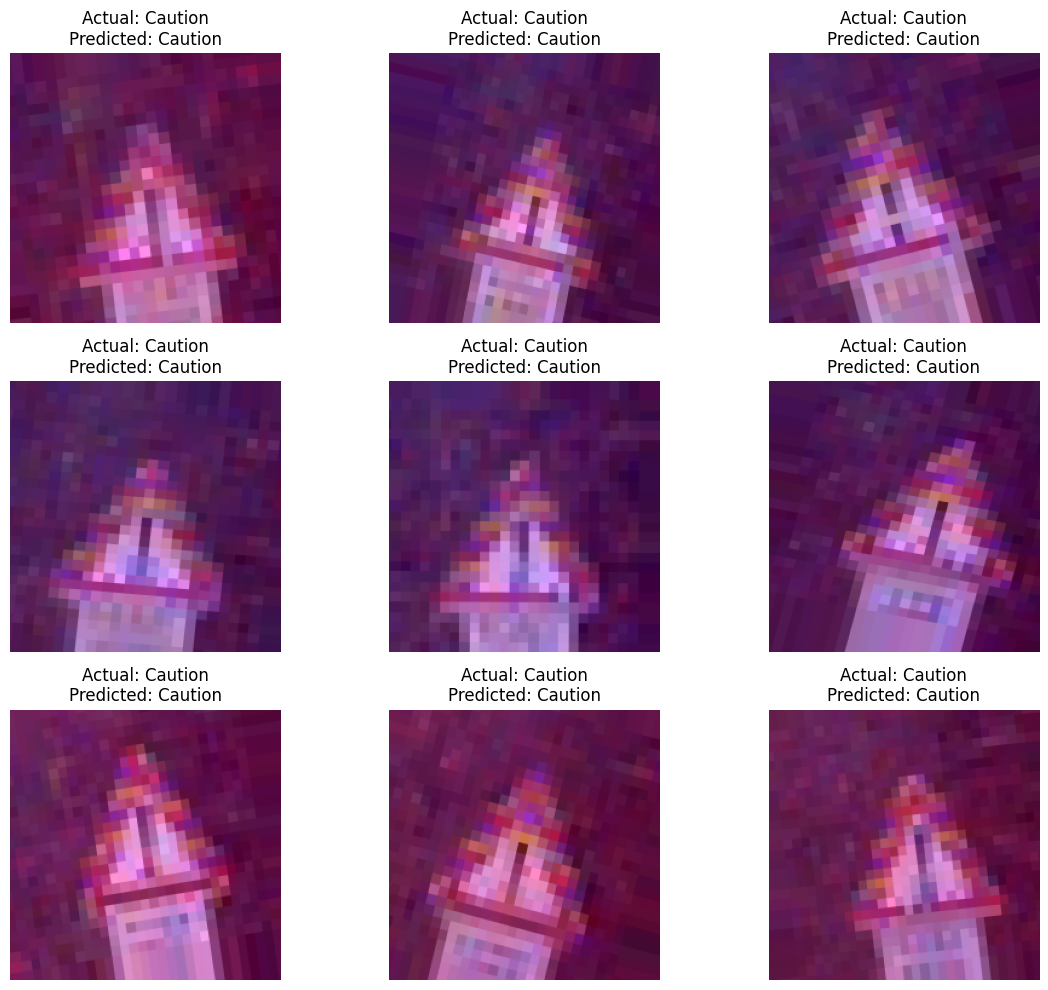

In [35]:
# DISPLAY SAMPLE PREDICTIONS

sample_images, sample_labels = next(transfer_val_data)

sample_predictions = transfer_model.predict(sample_images)

predicted_classes = np.argmax(sample_predictions, axis=1)

actual_classes = np.argmax(sample_labels, axis=1)

plt.figure(figsize=(12,10))

for i in range(min(9, len(sample_images))):

    plt.subplot(3,3,i+1)

    img = sample_images[i]

    # Rescale image for display
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    plt.title(
        "Actual: " + labels[actual_classes[i]]
        + "\nPredicted: " + labels[predicted_classes[i]]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()